## K-means Clustering and elbow method


In [1]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv("income - income.csv")

In [5]:
df


,name,age,income
0,Hritik,27,70000
1,Arpit,29,90000
2,Manav,29,61000
3,Kirti,28,60000
4,Siddhi,42,150000
5,Riya,39,155000
6,Ankita,41,160000
7,Vikash,38,162000
8,Priyank,36,156000
9,Kranti,35,130000


In [6]:
from matplotlib import pyplot as plt

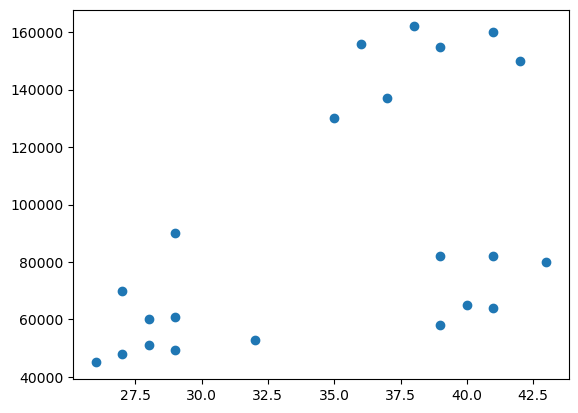

In [7]:
plt.scatter(df['age'],df['income'])

In [8]:
## Apply K-means
from sklearn.cluster import KMeans
kmean=KMeans(n_clusters=3)
kmean

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [9]:
y_predict=kmean.fit_predict(df[['age','income']])
y_predict

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0],
      dtype=int32)

In [10]:
df['cluster']=y_predict
df

,name,age,income,cluster
0,Hritik,27,70000,2
1,Arpit,29,90000,2
2,Manav,29,61000,0
3,Kirti,28,60000,0
4,Siddhi,42,150000,1
5,Riya,39,155000,1
6,Ankita,41,160000,1
7,Vikash,38,162000,1
8,Priyank,36,156000,1
9,Kranti,35,130000,1


In [11]:
kmean.predict([[34,50000]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([0], dtype=int32)

In [12]:
#divide the dataframe according to the cluster
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]

Text(0.5, 0, 'income')

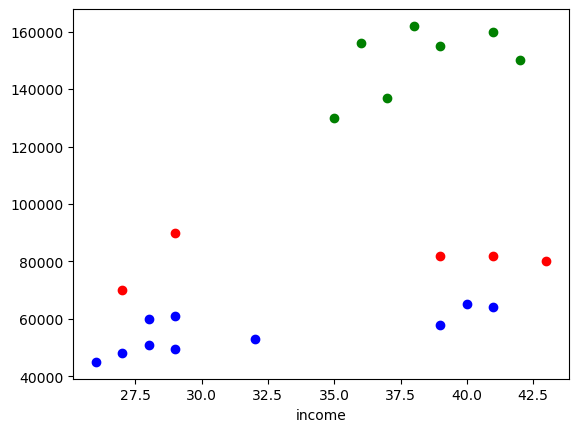

In [13]:
plt.scatter(df1.age,df1.income,color='blue')
plt.scatter(df2.age,df2.income,color='green')
plt.scatter(df3.age,df3.income,color='red')
plt.xlabel('age')
plt.xlabel('income')

## scale the attribute value from 0 to 1 by applying min-max Scaler

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
scaler=MinMaxScaler() #scaler is MinMaxScaler model

In [16]:
scaler.fit(df[['age']]) #fit() is used to train the model

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [17]:
df['AGE']=scaler.transform(df[['age']])
df

,name,age,income,cluster,AGE
0,Hritik,27,70000,2,0.058824
1,Arpit,29,90000,2,0.176471
2,Manav,29,61000,0,0.176471
3,Kirti,28,60000,0,0.117647
4,Siddhi,42,150000,1,0.941176
5,Riya,39,155000,1,0.764706
6,Ankita,41,160000,1,0.882353
7,Vikash,38,162000,1,0.705882
8,Priyank,36,156000,1,0.588235
9,Kranti,35,130000,1,0.529412


In [18]:
scaler.fit(df[['income']])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [19]:
df['Income']=scaler.transform(df[['income']])
df

,name,age,income,cluster,AGE,Income
0,Hritik,27,70000,2,0.058824,0.213675
1,Arpit,29,90000,2,0.176471,0.384615
2,Manav,29,61000,0,0.176471,0.136752
3,Kirti,28,60000,0,0.117647,0.128205
4,Siddhi,42,150000,1,0.941176,0.897436
5,Riya,39,155000,1,0.764706,0.940171
6,Ankita,41,160000,1,0.882353,0.982906
7,Vikash,38,162000,1,0.705882,1.000000
8,Priyank,36,156000,1,0.588235,0.948718
9,Kranti,35,130000,1,0.529412,0.726496


###  Again Apply k-means clustering on the scaled attribute

In [20]:
km=KMeans(n_clusters=3) # generate kmeans model
y_predict=km.fit_predict(df[['AGE','Income']])
y_predict

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [21]:
df['cluster']=y_predict
df.head()

,name,age,income,cluster,AGE,Income
0,Hritik,27,70000,0,0.058824,0.213675
1,Arpit,29,90000,0,0.176471,0.384615
2,Manav,29,61000,0,0.176471,0.136752
3,Kirti,28,60000,0,0.117647,0.128205
4,Siddhi,42,150000,1,0.941176,0.897436


Text(0.5, 0, 'income')

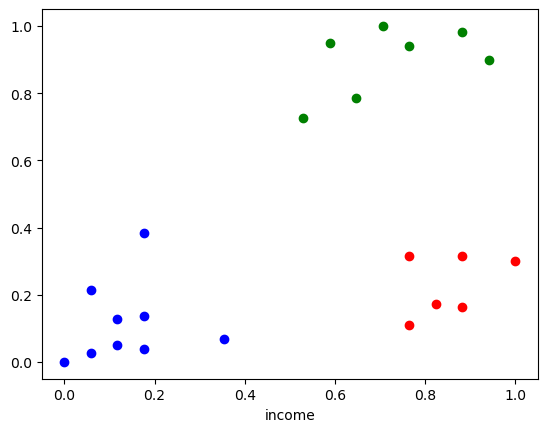

In [22]:

df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]
plt.scatter(df1.AGE,df1.Income,color='blue')
plt.scatter(df2.AGE,df2.Income,color='green')
plt.scatter(df3.AGE,df3.Income,color='red')
plt.xlabel('age')
plt.xlabel('income')

In [23]:
#display cluster means
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.22934473]])

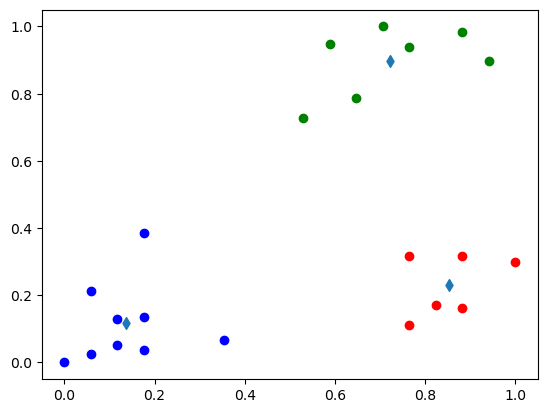

In [24]:
plt.scatter(df1.AGE,df1.Income,color='blue')
plt.scatter(df2.AGE,df2.Income,color='green')
plt.scatter(df3.AGE,df3.Income,color='red')
plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],marker='d')

## Elbow  Method

In [25]:
k_range=range(1,10)
sse=[]
for k in k_range:
    km=KMeans(n_clusters=k)
    km.fit(df[['AGE','Income']])
    sse.append(km.inertia_)
sse #noise created

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

[5.383034948191102,
 1.9781765163703693,
 0.4813242407165851,
 0.40891315890465646,
 0.2923176015302195,
 0.28437182111804304,
 0.1915488366002962,
 0.14429821534781173,
 0.10240408154856742]

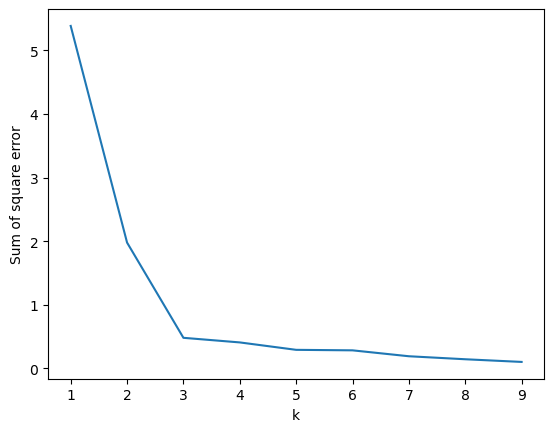

In [27]:
plt.xlabel('k')
plt.ylabel("Sum of square error")
plt.plot(k_range,sse)